# Signal lab: four ideas side by side, and a book built from them

Each idea is run with its costs and turned into a daily return series for 1x of equity (`src/research/signal_lab.py`), so they can be compared, correlated and combined.

| Sleeve | Idea | Status before this notebook (docs/research_log.md) |
|---|---|---|
| `carry` | Long the coins with the lowest funding, short the highest | Tested 2026-09-26: good in-sample, decayed afterwards |
| `momentum` | Rank coins by past 30-day return, direction fixed in-sample | Tested 2026-09-26: weak |
| `taker` | The taker-buy basket already in the paper book | The reference |
| `liquidation` | Fade forced-selling-shaped hours on BTC, ETH, SOL | Tested 2026-09-28 (H2, a proxy): failed |
| `variance_premium` | Sell BTC implied variance against realised | H3: the premium exists on BTC; **theoretical here**, no option prices |

**Read this first**
- In-sample is 2020-06 to 2023; holdout is 2024 to 2025. The frozen final holdout (2026) is locked and not used. The earlier studies' holdout ran into 2026, so their numbers differ from these.
- The cross-sectional sleeves use the coins Kraken lists **today**. A coin Kraken has delisted is missing from the past too, which flatters results.
- The book in section 3 is chosen on in-sample data only. Its holdout result is what that choice was worth afterwards.
- This notebook re-runs known configurations for display. A sleeve that looks good here still needs a pre-registration (`scripts/research/new_hypothesis.py`) before it goes into a config.

In [1]:
import os, sys, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT)); warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.research import signal_lab as lab
from src.utils.report import SERIES, style_axis
%matplotlib inline

pd.set_option("display.width", 200)
FORMATS = {"sharpe_in_sample": "{:.2f}", "sharpe_holdout": "{:.2f}", "return_in_sample": "{:+.1%}", "return_holdout": "{:+.1%}", "vol_holdout": "{:.1%}", "max_drawdown_holdout": "{:.1%}"}

def show(table, formats=FORMATS):
    """The table with its numbers formatted (plain pandas: `.style` would need jinja2)."""
    out = table.copy().astype(object)
    for column in table.columns:
        pattern = formats if isinstance(formats, str) else formats.get(column)
        if pattern:
            out[column] = [pattern.format(value) if pd.notna(value) else "" for value in table[column]]
    return out
sleeves = lab.build_sleeves()          # about 10 seconds; one public request to Kraken for its coin list
frame = lab.returns_frame(sleeves)
print(f"{len(sleeves)} sleeves, {frame.index[0]:%Y-%m-%d} to {frame.index[-1]:%Y-%m-%d}; holdout from {lab.HOLDOUT:%Y-%m-%d}")

5 sleeves, 2020-06-01 to 2025-12-31; holdout from 2024-01-01


## 1. Each sleeve by itself

In [2]:
table = lab.summary(sleeves)
table.insert(0, "tradable", [sleeves[name].tradable for name in table.index])
show(table)

,tradable,sharpe_in_sample,sharpe_holdout,return_in_sample,return_holdout,vol_holdout,max_drawdown_holdout
carry,True,1.09,0.93,+37.6%,+26.6%,28.5%,30.9%
momentum,True,-0.98,-0.63,-41.4%,-22.2%,35.0%,62.4%
taker,True,1.07,1.32,+38.7%,+33.2%,25.1%,19.1%
liquidation,True,0.17,-0.10,+3.2%,-1.1%,10.9%,17.2%
variance_premium,False,1.02,0.91,+17.7%,+8.5%,9.3%,8.2%


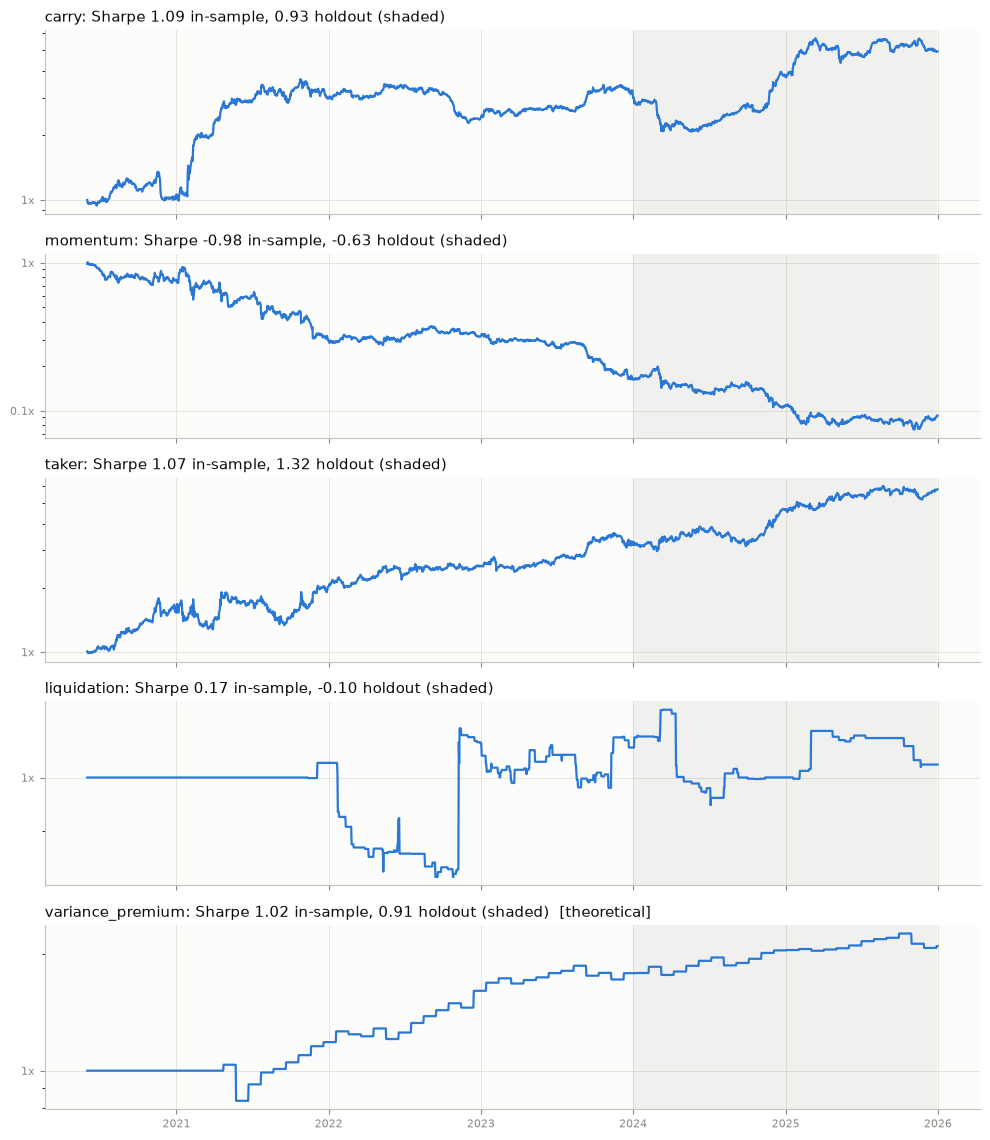

carry             Long the lowest 7-day funding, short the highest; weekly, market-neutral
                  Per year: price +26.2%, funding received +16.7%, costs -9.2%.
momentum          Rank by past 30-day return, direction fixed in-sample; weekly, market-neutral
                  In-sample sign -1 (reversal). Per year: price -21.4%, funding received -5.2%, costs -7.9%.
taker             Long the coins with the most aggressive buying over 7 days, short the least; weekly
                  Per year: price +40.9%, funding received +6.3%, costs -10.5%.
liquidation       Fade forced-selling-shaped hours on BTC, ETH, SOL; hold 24 h
                  200 trades in total: flat almost every day. A proxy, not real liquidation data.
variance_premium  Sell BTC 30-day implied variance against realised, monthly
                  Theoretical: no option bid/ask, margin or hedging cost, and its losses are far larger than its typical gain.


In [3]:
def curve(axis, returns, title):
    """Growth of 1, log scale, with the holdout shaded."""
    equity = (1.0 + returns).cumprod()
    axis.plot(equity.index, equity, color=SERIES[0], linewidth=1.6)
    axis.axvspan(lab.HOLDOUT, equity.index[-1], color="#898781", alpha=0.10, linewidth=0)
    axis.set_yscale("log"); axis.yaxis.set_major_formatter(lambda value, _: f"{value:g}x"); axis.yaxis.set_minor_formatter(lambda value, _: "")
    style_axis(axis, title)

figure, axes = plt.subplots(len(sleeves), 1, figsize=(10, 2.3 * len(sleeves)), sharex=True)
for axis, (name, sleeve) in zip(axes, sleeves.items()):
    row = table.loc[name]
    curve(axis, frame[name], f"{name}: Sharpe {row.sharpe_in_sample:.2f} in-sample, {row.sharpe_holdout:.2f} holdout (shaded)" + ("" if sleeve.tradable else "  [theoretical]"))
figure.tight_layout(); plt.show()
for name, sleeve in sleeves.items():
    print(f"{name:<17} {sleeve.description}\n{'':<17} {sleeve.note}")

**How to read these**
- `carry`, `momentum` and `taker` are market-neutral long/short books at 1x gross, with Kraken's taker fee, slippage by liquidity and each coin's real funding.
- `liquidation` trades about 200 times in five and a half years, so it is flat almost every day and its Sharpe says little.
- `variance_premium` has no costs and no real option prices. Selling variance earns a little most months and loses a lot in a few; the smooth line understates that risk.
- `momentum` shows why it is not a signal here: the in-sample rank correlation says reversal, yet the top-against-bottom book traded that way lost in-sample, and on 30 coins the sign flips (section 5).

## 2. How alike are they?

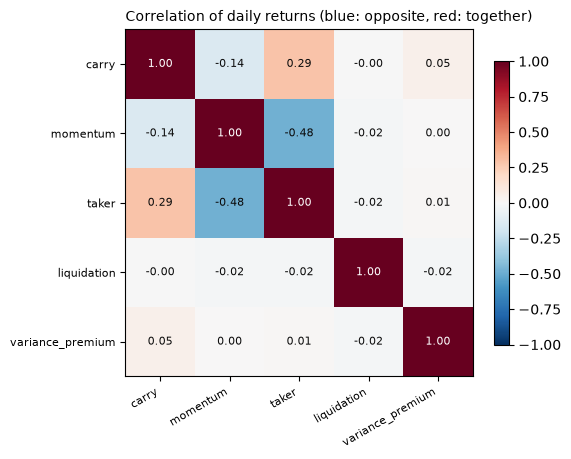

In [4]:
correlation = frame.corr()
figure, axis = plt.subplots(figsize=(5.6, 4.6))
image = axis.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
axis.set_xticks(range(len(correlation)), correlation.columns, rotation=30, ha="right", fontsize=8); axis.set_yticks(range(len(correlation)), correlation.index, fontsize=8)
for i in range(len(correlation)):
    for j in range(len(correlation)):
        axis.text(j, i, f"{correlation.iat[i, j]:.2f}", ha="center", va="center", fontsize=8, color="white" if abs(correlation.iat[i, j]) > 0.6 else "#0b0b0b")
axis.set_title("Correlation of daily returns (blue: opposite, red: together)", fontsize=10, loc="left"); figure.colorbar(image, shrink=0.8); plt.show()

## 3. The book it likes

`lab.choose` takes the tradable sleeves whose **in-sample** Sharpe is at least `MIN_SHARPE` and weights them by inverse in-sample volatility. It never sees the holdout.

In [5]:
MIN_SHARPE = 0.5
weights, chosen = lab.combine(sleeves, min_sharpe=MIN_SHARPE)
print("Chosen in-sample:", {name: f"{weight:.0%}" for name, weight in weights.items()})
print("Left out:", [name for name in sleeves if name not in weights])
books = pd.DataFrame({"chosen book": chosen})
show(lab.summary(books))

Chosen in-sample: {'carry': '51%', 'taker': '49%'}
Left out: ['momentum', 'liquidation', 'variance_premium']


,sharpe_in_sample,sharpe_holdout,return_in_sample,return_holdout,vol_holdout,max_drawdown_holdout
chosen book,1.32,1.47,+38.1%,+29.8%,20.3%,15.8%


## 4. A preset you set

Edit `PRESET` (sleeve name -> weight; they are scaled to sum to 1) and re-run. A preset may include `variance_premium`, but remember it is theoretical.

Preset: {'carry': '40%', 'taker': '40%', 'liquidation': '20%'}


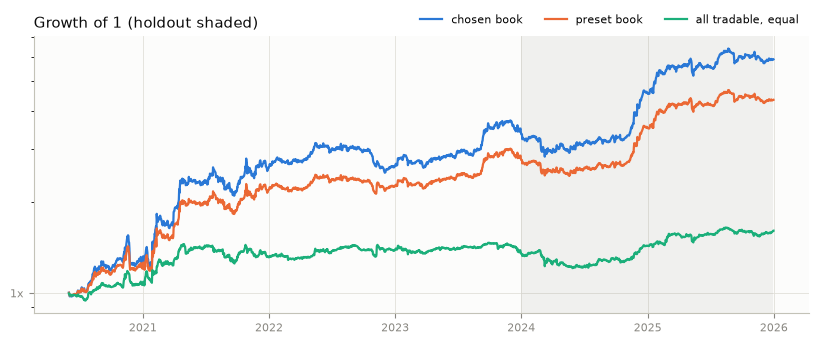

,sharpe_in_sample,sharpe_holdout,return_in_sample,return_holdout,vol_holdout,max_drawdown_holdout
chosen book,1.32,1.47,+38.1%,+29.8%,20.3%,15.8%
preset book,1.34,1.46,+31.2%,+23.7%,16.3%,11.3%
"all tradable, equal",0.65,0.82,+9.5%,+9.1%,11.1%,12.7%


In [6]:
PRESET = {"carry": 1.0, "taker": 1.0, "liquidation": 0.5}
preset_weights, preset = lab.combine(sleeves, PRESET)
print("Preset:", {name: f"{weight:.0%}" for name, weight in preset_weights.items()})
books["preset book"] = preset
equal_weights, books["all tradable, equal"] = lab.combine(sleeves, {name: 1.0 for name, sleeve in sleeves.items() if sleeve.tradable})

figure, axis = plt.subplots(figsize=(10, 3.6))
for color, column in zip(SERIES, books.columns):
    equity = (1.0 + books[column]).cumprod(); axis.plot(equity.index, equity, color=color, linewidth=1.6, label=column)
axis.axvspan(lab.HOLDOUT, books.index[-1], color="#898781", alpha=0.10, linewidth=0)
axis.set_yscale("log"); axis.yaxis.set_major_formatter(lambda value, _: f"{value:g}x"); axis.yaxis.set_minor_formatter(lambda value, _: "")
style_axis(axis, "Growth of 1 (holdout shaded)"); axis.legend(frameon=False, fontsize=8, loc="lower right", bbox_to_anchor=(1.0, 1.0), ncols=3); plt.show()
show(lab.summary(books))

## 5. How much depends on the universe size?

The cross-sectional sleeves on the 30 most traded Kraken-listed coins instead of 50. If a result only holds for one size, it is not a result.

In [7]:
rows = {}
for top_n in (30, 50):
    wide = lab.load_universe(top_n=top_n)
    names = int(wide["universe"].sum(axis=1)[wide["universe"].index >= lab.START].median())
    for sleeve in (lab.carry_sleeve(wide), lab.momentum_sleeve(wide), lab.taker_sleeve(wide)):
        numbers = lab.summary({sleeve.name: sleeve}).iloc[0]
        rows[(sleeve.name, f"top {top_n} ({names} coins on a median day)")] = {"Sharpe in-sample": numbers.sharpe_in_sample, "Sharpe holdout": numbers.sharpe_holdout, "max drawdown holdout": numbers.max_drawdown_holdout}
show(pd.DataFrame(rows).T.sort_index(), {"Sharpe in-sample": "{:.2f}", "Sharpe holdout": "{:.2f}", "max drawdown holdout": "{:.1%}"})

Sharpe in-sample Sharpe holdout max drawdown holdout
carry    top 30 (24 coins on a median day)             1.77           1.63                23.7%
         top 50 (36 coins on a median day)             1.09           0.93                30.9%
momentum top 30 (24 coins on a median day)             0.67           0.27                31.6%
         top 50 (36 coins on a median day)            -0.98          -0.63                62.4%
taker    top 30 (24 coins on a median day)             1.44           1.08                23.3%
         top 50 (36 coins on a median day)             1.07           1.32                19.1%

## 6. Holdout, year by year

In [8]:
yearly = pd.concat([frame, books], axis=1).groupby(lambda stamp: stamp.year).apply(lambda part: part.mean() / part.std() * np.sqrt(365))
show(yearly, "{:.2f}")  # Sharpe per calendar year

,carry,momentum,taker,liquidation,variance_premium,chosen book,preset book,"all tradable, equal"
2020,0.25,-1.01,2.46,,,1.52,1.55,0.82
2021,2.26,-1.19,0.79,0.96,0.81,1.87,1.86,1.13
2022,-0.97,0.36,1.06,0.26,1.79,0.15,0.29,0.53
2023,1.36,-2.03,1.05,-0.01,0.97,1.51,1.47,-0.18
2024,0.76,-0.96,1.56,-0.41,1.34,1.47,1.44,0.52
2025,1.14,-0.30,1.05,0.33,0.37,1.47,1.49,1.20


## 7. The two ideas that are waiting for data

Real liquidations and option chains can't be downloaded after the fact, so the collectors record them. Until there are months of them, `liquidation` runs on a proxy and `variance_premium` is theoretical. File counts only; this notebook does not read their prices (they fall in the locked 2026 holdout).

In [9]:
lab.recorded_coverage()

,files,days,first,last,megabytes
data,,,,,
Binance liquidations,7,7,2026-09-26,2026-10-03,2.18
Bybit liquidations,6,6,2026-09-26,2026-10-02,0.08
Deribit BTC option chains,65,8,2026-09-26,2026-10-04,4.75
Deribit ETH option chains,64,8,2026-09-26,2026-10-04,4.08


## What to take from this

- **Chosen in-sample: carry and taker, about half each.** That book made a Sharpe of 1.3 in-sample and 1.5 in the 2024-2025 holdout, with a 16% drawdown. The two are nearly uncorrelated (0.16), which is what makes the pair better than either.
- **Treat that number with suspicion.** The coin list is today's Kraken listing (looks ahead), the holdout has now been looked at more than once, and the earlier carry study, whose holdout ran to August 2026, measured carry at 0.42, not 0.93. Carry also lost in 2022 and depends on the universe size (1.6 on 30 coins, 0.9 on 50).
- **Momentum is not a signal on this universe**, the liquidation proxy does nothing (the real test waits for recorded liquidations), and the variance premium can't be judged without option prices.
- These are re-runs for display, not new evidence. Next step for carry: a pre-registration (`scripts/research/new_hypothesis.py`) with one configuration and a point-in-time coin list, then its overlap with the running book (`src/portfolio/backtest.candidate_report`), before it goes into a config.